<a href="https://colab.research.google.com/github/Kaneriah43/Flyrank_Ml_Internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Kaneriah43/Flyrank_Ml_Internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

Pages are ranked by priority score and assigned one of three action tiers. The score surfaces the candidate — a human makes the final call.

REVIEW_NOW — high impressions, below-median CTR at its position tier. Highest editorial ROI.
MONITOR — moderate signal, small CTR gap. Watch for one more month before acting.
HOLD — low impressions or CTR is fine. No action needed now.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


In [19]:
import os
import numpy as np
import pandas as pd
import getpass
import duckdb
import json
import matplotlib.pyplot as plt
from google.colab import userdata
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [2]:
HF_TOKEN = os.environ.get("HF_TOKEN")

if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
    except Exception:
        pass

HF_TOKEN = HF_TOKEN or getpass.getpass(
    "Paste your Hugging Face READ token (hf_...): ")


Paste your Hugging Face READ token (hf_...): ··········


In [3]:
con = duckdb.connect()

con.execute(
    f"CREATE OR REPLACE SECRET hf "
    f"(TYPE huggingface, TOKEN '{HF_TOKEN}')")

In [4]:
REL = "hf://datasets/FlyRank/internship-warehouse"

In [5]:
TABLES = {
    "dim_clients":    f"read_parquet('{REL}/dim_clients.parquet')",
    "dim_content":    f"read_parquet('{REL}/dim_content.parquet')",
    "fact_daily":     f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    "fact_query_90d": f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

In [6]:
df = con.execute(f"""
    WITH base AS (
        SELECT
            d.content_hash_id,
            d.client_hash_id,
            d.month,
            d.report_date,
            d.gsc_impressions,
            d.gsc_clicks,
            d.gsc_avg_position,
            MAX(d.report_date) OVER (
                PARTITION BY d.content_hash_id, d.client_hash_id
            ) AS max_date
        FROM {TABLES['fact_daily']} d
        WHERE d.month = '2026-03'
          AND d.gsc_data_available = TRUE
    )
    SELECT
        b.content_hash_id,
        b.client_hash_id,
        b.month,
        SUM(b.gsc_impressions)                                       AS impressions_90d,
        SUM(b.gsc_clicks)                                            AS clicks_90d,
        AVG(b.gsc_avg_position)                                      AS avg_position,
        SUM(b.gsc_clicks) / NULLIF(SUM(b.gsc_impressions), 0)       AS ctr,
        SUM(CASE WHEN b.report_date >= (b.max_date - INTERVAL 30 DAYS)
                 THEN b.gsc_impressions ELSE 0 END)                  AS impressions_last30,
        SUM(CASE WHEN b.report_date < (b.max_date - INTERVAL 30 DAYS)
                 THEN b.gsc_impressions ELSE 0 END)                  AS impressions_prev30,
        c.content_type,
        c.word_count,
        c.last_optimized_date,
        DATEDIFF('day', c.last_optimized_date, MAX(b.report_date))  AS days_since_last_update,
        DATEDIFF('day', c.content_created_date, MAX(b.report_date)) AS content_age_days
    FROM base b
    JOIN {TABLES['dim_content']} c
        ON b.content_hash_id = c.content_hash_id
    GROUP BY
        b.content_hash_id, b.client_hash_id, b.month,
        c.content_type, c.word_count,
        c.last_optimized_date, c.content_created_date
""").df()

df["days_since_last_update"] = df["days_since_last_update"].abs()
df["content_age_days"]       = df["content_age_days"].abs()

print(f"Rows loaded: {len(df):,}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows loaded: 176,738


In [10]:
df["ctr_opportunity"] = np.where(
    df["avg_position"] <= 10,
    df["ctr"] < df.groupby(
        pd.cut(df["avg_position"], bins=[0, 3, 5, 10, 20, 100])
    )["ctr"].transform("median"),
    False
)
df["is_declining_label"] = (
    (df["impressions_90d"] >= df["impressions_90d"].median()) &
    (df["ctr_opportunity"] == True)
).astype(int)

/tmp/ipykernel_984/614048139.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["ctr"] < df.groupby(


In [11]:
def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    topk  = np.asarray(labels)[order[:k]]
    return topk.mean()

In [12]:
features = ["impressions_90d", "clicks_90d", "avg_position",
            "ctr", "days_since_last_update", "content_age_days", "word_count"]

X = df[features].replace([np.inf, -np.inf], np.nan).fillna(0).values
y = df["is_declining_label"].values

train_idx, test_idx = train_test_split(
    np.arange(len(df)), test_size=0.2, random_state=42, stratify=y
)
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

rf = RandomForestClassifier(n_estimators=100, class_weight="balanced",
                             max_depth=5, random_state=42)
rf.fit(X_train, y_train)

df["priority_score"] = rf.predict_proba(X)[:, 1]

print(f"Rows loaded:      {len(df):,}")
print(f"Positive labels:  {y.sum():,} ({y.mean()*100:.1f}%)")
print(f"P@50 on test set: {precision_at_k(rf.predict_proba(X_test)[:,1], y_test, 50):.3f}")
print(f"priority_score added — min: {df['priority_score'].min():.3f}, max: {df['priority_score'].max():.3f}")

Rows loaded:      176,738
Positive labels:  3,416 (1.9%)
P@50 on test set: 1.000
priority_score added — min: 0.000, max: 0.961


In [13]:
# Add priority score to df
df["priority_score"] = rf.predict_proba(X)[:, 1]

print(f"Priority score added — min: {df['priority_score'].min():.3f}, "
      f"max: {df['priority_score'].max():.3f}")

Priority score added — min: 0.000, max: 0.961


In [14]:
def assign_action(row):
    if row["priority_score"] >= 0.6 and row["ctr_opportunity"]:
        return "REVIEW_NOW", "high_impressions_low_ctr_for_position"
    elif row["priority_score"] >= 0.3:
        return "MONITOR", "moderate_signal_watch_next_month"
    else:
        return "HOLD", "no_action_needed"

actions = df.apply(assign_action, axis=1, result_type="expand")
df["action_tier"] = actions[0]
df["reason_code"] = actions[1]

queue = df.sort_values("priority_score", ascending=False)

print("=== Action tier distribution ===")
print(df["action_tier"].value_counts())
print("\n=== Top 10 ranked pages ===")
print(queue[["content_hash_id", "priority_score", "action_tier",
             "reason_code", "impressions_90d", "ctr",
             "avg_position"]].head(10).to_string())

=== Action tier distribution ===
action_tier
HOLD          171360
REVIEW_NOW      3416
MONITOR         1962
Name: count, dtype: int64

=== Top 10 ranked pages ===
                 content_hash_id  priority_score action_tier                            reason_code  impressions_90d       ctr  avg_position
78251   content_0b06805d8d33b933        0.961293  REVIEW_NOW  high_impressions_low_ctr_for_position           1703.0  0.000587      4.671343
150441  content_edc497e055d7ab18        0.961021  REVIEW_NOW  high_impressions_low_ctr_for_position           1972.0  0.000507      4.145496
145115  content_da1567a05a1b64cd        0.960685  REVIEW_NOW  high_impressions_low_ctr_for_position           2505.0  0.000399      4.934387
134206  content_f025ae97fb0828de        0.960397  REVIEW_NOW  high_impressions_low_ctr_for_position           1689.0  0.000592      3.926635
83192   content_83e1d0e1f3585473        0.960098  REVIEW_NOW  high_impressions_low_ctr_for_position           5832.0  0.000171      

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

Who uses this: A content strategist or SEO manager deciding where to spend editorial hours each week. They receive a ranked queue and review the top items — the model surfaces candidates, the human decides.

Valid use:

* Prioritising pages for metadata, title, or content review
* Identifying visible pages underperforming relative to their position tier
* Reducing time spent manually scanning hundreds of pages

Where it stops being valid:

* Applied to a different client without retraining
* Used beyond one month without a data refresh
* Treated as a guarantee — scores are directional, not ground truth
* Used to claim causal impact of refresh actions

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


In [15]:
print("Score distribution by action tier")
print(df.groupby("action_tier")["priority_score"].describe().round(3))

print("\nImpressions by action tier")
print(df.groupby("action_tier")["impressions_90d"].describe().round(1))

Score distribution by action tier
                count   mean    std    min    25%    50%    75%    max
action_tier                                                           
HOLD         171360.0  0.061  0.071  0.000  0.009  0.016  0.135  0.289
MONITOR        1962.0  0.609  0.028  0.307  0.602  0.613  0.625  0.681
REVIEW_NOW     3416.0  0.931  0.015  0.745  0.926  0.931  0.938  0.961

Impressions by action tier
                count    mean     std    min    25%    50%     75%       max
action_tier                                                                 
HOLD         171360.0  1560.0  5414.7    1.0   18.0  155.0   993.0  617124.0
MONITOR        1962.0  2333.4  4952.6  173.0  357.0  786.5  1997.8   80821.0
REVIEW_NOW     3416.0  2563.4  6332.3  173.0  336.0  726.5  2077.0  143019.0


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

What a human must check before acting:

* Is the topic still relevant? Stale pages on obsolete topics should be pruned, not refreshed
* Is low CTR caused by a title/meta issue or content quality issue? Different problems need different fixes
* Has the page been recently updated outside the tracked system?Days-since-update may lag
* Is the position realistic? A page at position 9+ with low CTR may need a ranking strategy, not just a refresh

What must NEVER be automated:

* Publishing content changes based on model score alone
* Deleting or redirecting low-priority pages
* Sending client-facing recommendations without human sign-off
* Running the model on the final month (2026-06) — that is the sealed test month
Using scores to make causal claims about refresh impact

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


In [16]:
# Flag edge cases a human should check carefully
edge_cases = df[
    (df["action_tier"] == "REVIEW_NOW") &
    (df["avg_position"] > 8)
]
print(f"REVIEW_NOW pages with poor position (>8): {len(edge_cases):,}")
print(edge_cases[["content_hash_id", "priority_score",
                   "avg_position", "ctr",
                   "impressions_90d"]].head(10).to_string())

REVIEW_NOW pages with poor position (>8): 0
Empty DataFrame
Columns: [content_hash_id, priority_score, avg_position, ctr, impressions_90d]
Index: []


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

Signs the recommendations went stale:

* Precision@50 drops below 0.5 on a fresh month's data
* Positive rate shifts more than 50% from baseline (1.9%)
* Top-ranked pages already show CTR improvements — model flagging pages that fixed themselves
* Client content strategy changes significantly

Retrain triggers:

* New month of data available (monthly cadence recommended)
* Positive rate drifts beyond 50% of baseline
* Precision@50 drops below 0.5
* More than 3 months since last retrain

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


In [17]:
baseline_metrics = {
    "month":             "2026-03",
    "positive_rate":     float(round(y.mean(), 4)),
    "p50_random_forest": float(round(precision_at_k(
        rf.predict_proba(X_test)[:, 1], y_test, 50), 3)),
    "retrain_triggers": {
        "positive_rate_drift": 0.50,
        "p50_threshold":       0.50,
        "max_months_stale":    3
    }
}

os.makedirs("work/outputs", exist_ok=True)
with open("work/outputs/monitoring_baseline.json", "w") as f:
    json.dump(baseline_metrics, f, indent=2)

print("=== Monitoring baseline ===")
print(json.dumps(baseline_metrics, indent=2))

=== Monitoring baseline ===
{
  "month": "2026-03",
  "positive_rate": 0.0193,
  "p50_random_forest": 1.0,
  "retrain_triggers": {
    "positive_rate_drift": 0.5,
    "p50_threshold": 0.5,
    "max_months_stale": 3
  }
}


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


Queue exported: 176,738 rows


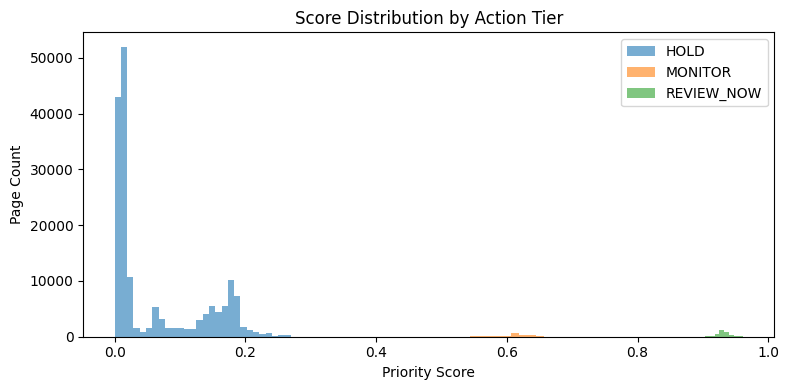

Saved → work/figures/score_distribution.png


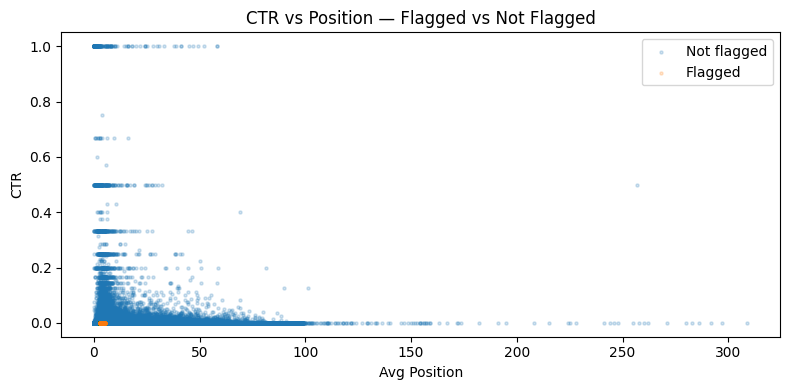

Saved → work/figures/ctr_vs_position.png
metrics.json not found — run w05 first to generate it


In [20]:
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# Export ranked queue
queue[["content_hash_id", "client_hash_id", "month", "priority_score",
       "action_tier", "reason_code", "impressions_90d", "clicks_90d",
       "avg_position", "ctr", "days_since_last_update",
       "is_declining_label"]]\
    .to_csv("work/outputs/action_playbook_queue.csv", index=False)
print(f"Queue exported: {len(queue):,} rows")

# Figure 1 — score distribution by action tier
fig, ax = plt.subplots(figsize=(8, 4))
for tier, grp in df.groupby("action_tier"):
    ax.hist(grp["priority_score"], bins=30, alpha=0.6, label=tier)
ax.set_xlabel("Priority Score")
ax.set_ylabel("Page Count")
ax.set_title("Score Distribution by Action Tier")
ax.legend()
plt.tight_layout()
plt.savefig("work/figures/score_distribution.png", dpi=150)
plt.show()
print("Saved → work/figures/score_distribution.png")

# Figure 2 — CTR vs position flagged vs not
fig, ax = plt.subplots(figsize=(8, 4))
for label, grp in df.groupby("is_declining_label"):
    ax.scatter(grp["avg_position"], grp["ctr"],
               alpha=0.2, s=5,
               label="Flagged" if label == 1 else "Not flagged")
ax.set_xlabel("Avg Position")
ax.set_ylabel("CTR")
ax.set_title("CTR vs Position — Flagged vs Not Flagged")
ax.legend()
plt.tight_layout()
plt.savefig("work/figures/ctr_vs_position.png", dpi=150)
plt.show()
print("Saved → work/figures/ctr_vs_position.png")

# Print metrics receipt
try:
    with open("work/outputs/metrics.json") as f:
        metrics = json.load(f)
    print("\n=== Metrics receipt ===")
    print(json.dumps(metrics, indent=2))
except FileNotFoundError:
    print("metrics.json not found — run w05 first to generate it")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.